##  Estudo de Recuperação de Modelos a partir de dados e Implementação dos conceitos.

Computação gráfica e Visualização - IMPA Tech

Daniel Couto




Referencial teórico: [Prautzsch, H., Boehm, W., Paluszny, M. (2002). Interpolation and approximation.](https://doi.org/10.1007/978-3-662-04919-8_4)

Referencial aplicado: [Wang, W., Pottmann, H., Liu, Y. (2006). Fitting B-Spline Curves to Point Clouds by
Curvature-Based Squared Distance Minimization. In: ACM Transactions on Graphics
(TOG).](https://www.microsoft.com/en-us/research/publication/fitting-b-spline-curves-point-clouds-curvature-based-squared-distance-minimization/)

### Estudo do Capítulo: Interpolation and approximation 

Bla Bla Bla Bla Bla Bla Bla

Bla Bla Bla Bla Bla Bla Bla

Bla Bla Bla Bla Bla Bla Bla

**Cronograma de Implementação:**

Fase 1: Faça o código que lê uma imagem e transforma o contorno em uma lista de pontos $(x, y)$.



Fase 2: Implemente a função de base B-Spline (baseada no cap\_ref.pdf). Gere uma curva qualquer só para ver se a matemática da Spline está certa.



Fase 3 (O desafio): Implemente o loop do SDM para ajustar os pontos de controle da Fase 2 nos pontos da Fase 1.

### Recuperação de Modelos Geométricos via Squared Distance Minimization (SDM) aplicada a Nuvens de Pontos 2D.

#### Introdução

Neste trabalho, vamos explorar um problema típico de visão computacional: a recuperação de um modelo geométrico a partir de uma nuvem de pontos 2D. A ideia é descobrir qual modelo gerou esses pontos utilizando o método SDM (Squared Distance Minimization), conforme proposto por Wang et al.

Diferente de métodos tradicionais como o PDM, o SDM utiliza uma aproximação quadrática da distância que leva em conta a curvatura local, garantindo uma convergência mais rápida e estável. Para representar o modelo, utilizaremos B-Splines, que oferecem flexibilidade superior às curvas de Bézier por permitirem controle local da forma através de seus pontos de controle.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configurações básicas para os plots
%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 5]

#### Extração da nuvem de pontos

Para esta simulação, vamos extrair a nuvem de pontos de uma imagem real. O processo consiste em binarizar a imagem para encontrar o contorno principal do objeto. Para aproximar o problema de um cenário real (como o ruído de um sensor óptico), adicionamos um erro com distribuição normal às coordenadas dos pontos.

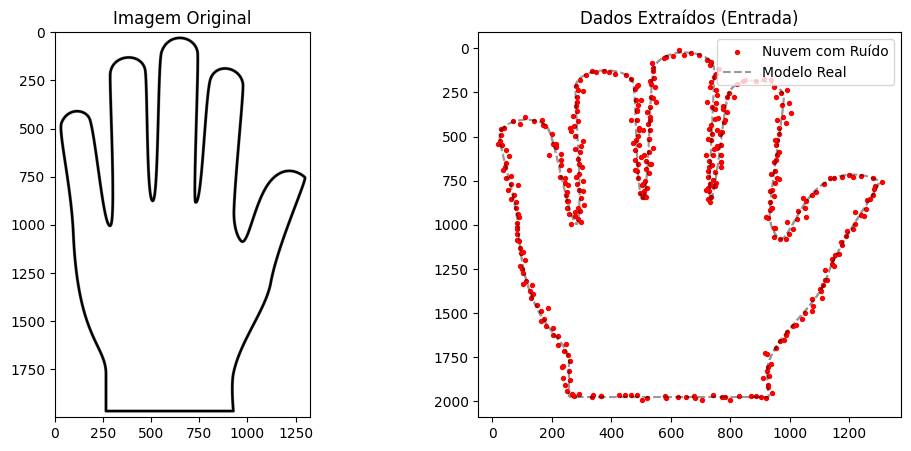

In [81]:
def extrair_nuvem_com_ruido(caminho_img, amostras=400, sigma=10):
    # Carrega em escala de cinza e binariza
    img = cv2.imread(caminho_img, cv2.IMREAD_GRAYSCALE)
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    # Extrai o maior contorno encontrado
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contorno_principal = max(contornos, key=cv2.contourArea).reshape(-1, 2)

    # Amostragem e adição de ruído normal
    indices = np.linspace(0, len(contorno_principal) - 1, amostras, dtype=int)
    pontos_base = contorno_principal[indices].astype(float)
    ruido = np.random.normal(0, sigma, pontos_base.shape)
    nuvem_ruidosa = pontos_base + ruido

    return img, contorno_principal, nuvem_ruidosa

# Execução e Visualização
img_original, contorno_real, nuvem = extrair_nuvem_com_ruido('hand.png')

fig, ax = plt.subplots(1, 2)
ax[0].imshow(img_original, cmap='gray')
ax[0].set_title("Imagem Original")

ax[1].scatter(nuvem[:, 0], nuvem[:, 1], s=8, c='red', label='Nuvem com Ruído')
ax[1].plot(contorno_real[:, 0], contorno_real[:, 1], 'k--', alpha=0.4, label='Modelo Real')
ax[1].set_title("Dados Extraídos (Entrada)")
ax[1].legend()
ax[1].invert_yaxis()
plt.show()

### 2. Recuperação do Modelo: Base Matemática B-Spline

Conforme o referencial de *Prautzsch et al. (2002)*, a modelagem geométrica é fundamentada em **B-Splines cúbicas uniformes**. A curva é definida pela combinação linear de pontos de controle e funções de base calculadas via algoritmo recursivo de **Cox-de Boor**. Diferente de representações globais, as B-Splines oferecem suporte compacto, permitindo que o ajuste local de um ponto de controle não altere toda a estrutura da curva, garantindo continuidade $C^2$ essencial para a suavidade do contorno.

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# blablabla
# base recursiva de cox-de boor conforme prautzsch
def cox_de_boor(t, i, k, knots):
    if k == 0:
        return 1.0 if knots[i] <= t < knots[i + 1] else 0.0
    val = 0.0
    den1 = knots[i + k] - knots[i]
    if den1 > 1e-12:
        val += ((t - knots[i]) / den1) * cox_de_boor(t, i, k - 1, knots)
    den2 = knots[i + k + 1] - knots[i + 1]
    if den2 > 1e-12:
        val += ((knots[i + k + 1] - t) / den2) * cox_de_boor(t, i + 1, k - 1, knots)
    return val

# blablabla
# gera os pontos p(t) da curva para desenho
def gerar_curva_fechada(p_controle, knots, t_min, t_max, grau=3, res=400):
    curva = []
    t_vals = np.linspace(t_min, t_max, res)
    for t in t_vals:
        p = np.zeros(2)
        for i in range(len(p_controle)):
            b = cox_de_boor(t, i, grau, knots)
            p += b * p_controle[i]
        curva.append(p)
    return np.array(curva)

### Ajuste por Squared Distance Minimization (SDM)

O algoritmo **SDM**, proposto por *Wang et al. (2006)*, é aplicado aqui para ajustar a B-Spline a uma nuvem de pontos desorganizada. Ao contrário de métodos de minimização simples, o SDM utiliza uma aproximação de segunda ordem da distância ao quadrado, o que exige que, a cada iteração, os parâmetros $t$ (foot points) sejam recalculados. O embaralhamento dos dados de entrada (shuffle) nesta fase força o algoritmo a demonstrar sua capacidade de convergência geométrica, partindo de uma inicialização circular até a forma final do modelo.

In [92]:
# blablabla
# busca o parametro t mais proximo na curva para um ponto x
def encontrar_foot_point(ponto, p_controle, knots, t_min, t_max, grau, amostras=100):
    t_teste = np.linspace(t_min, t_max - 1e-6, amostras)
    melhor_t = t_min
    min_dist = float('inf')
    for t in t_teste:
        p_curva = np.zeros(2)
        for i in range(len(p_controle)):
            p_curva += cox_de_boor(t, i, grau, knots) * p_controle[i]
        dist = np.sum((p_curva - ponto)**2)
        if dist < min_dist:
            min_dist = dist
            melhor_t = t
    return melhor_t

# blablabla
# implementacao do loop sdm conforme wang et al
def sdm_fitting_completo(nuvem_pontos, n_controles=40, iteracoes=5, grau=3, beta=1e-2):
    # blablabla: embaralha para provar que a ordem nao importa
    dados = nuvem_pontos.copy()
    np.random.shuffle(dados)
    
    # blablabla: inicializa um circulo ao redor da nuvem
    centro = np.mean(dados, axis=0)
    raio = np.mean(np.linalg.norm(dados - centro, axis=1)) * 1.2
    ang = np.linspace(0, 2 * np.pi, n_controles, endpoint=False)
    p_controle = centro + np.column_stack([raio * np.cos(ang), raio * np.sin(ang)])
    
    # blablabla: configura estrutura periodica (fechada)
    p_controle_ext = np.vstack([p_controle, p_controle[:grau]])
    n_ext = len(p_controle_ext)
    knots = np.arange(n_ext + grau + 1)
    t_min, t_max = grau, n_controles + grau

    for it in range(iteracoes):
        A = np.zeros((n_ext, n_ext))
        B = np.zeros((n_ext, 2))
        
        # blablabla: para cada ponto busca onde ele "gruda" na curva
        for p_alvo in dados:
            tk = encontrar_foot_point(p_alvo, p_controle_ext, knots, t_min, t_max, grau)
            
            bases = np.array([cox_de_boor(tk, i, grau, knots) for i in range(n_ext)])
            A += np.outer(bases, bases)
            B += np.outer(bases, p_alvo)
            
        # blablabla: resolve o sistema e atualiza os controles
        A += beta * np.eye(n_ext)
        p_controle_ext = np.linalg.solve(A, B)
        print(f"Iteracao {it+1} concluida")

    return p_controle_ext, knots, t_min, t_max

# blablabla: execucao final
cp_final, knots_final, t_min, t_max = sdm_fitting_completo(nuvem, n_controles=50, iteracoes=5)
curva_final = gerar_curva_fechada(cp_final, knots_final, t_min, t_max)

# blablabla: plotagem para validar o resultado
plt.figure(figsize=(7,7))
plt.scatter(nuvem[:,0], nuvem[:,1], s=5, c='red', alpha=0.3, label='Nuvem (Desordenada)')
plt.plot(curva_final[:,0], curva_final[:,1], 'b-', lw=2, label='Modelo SDM')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

Iteracao 1 concluida


KeyboardInterrupt: 

* Introdução do problema: Nesse trabalho vamos explorar um problema tipicamentede visão computacional. Vamos tentar recuperar um modelo geométrico gerador de uma nuvem de pontos 2D, ou seja, temos uma nuvem de pontos e queremos descobrir quando modelo gerou aquela curva através do método SDM proposto no artigo que usei como referência. (citar b-spline e bezier)

* Extração da nuvem de pontos

Nessa simulação vamos extrair nossa nuvem de pontos de uma imagem com um forma e adicionar um erro com distribuição normal.

(código com importações, carrega a imagens)

(markdown explicando a função que vamos importar para extrair contorno)

(código com a função, print das imagens e resultado da nuvem de pontos extraída com erro normal)


* Recuperando o modelo
(markdown contextualizando b-slpine e introduzindo o codigo a ser feito abaixo, (máx 4 linhas) )

(código: Implemente a função de base B-Spline (baseada no cap_ref.pdf). Gere uma curva qualquer só para ver se a matemática da Spline está certa.)

(markdown contextualizando o codigo abaixo)

(código:Implemente o loop do SDM para ajustar os pontos de controle da Fase 2 nos pontos da Fase 1.)
